In [1]:
import kagglehub
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
['Training', 'Testing']


In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

In [3]:
training_path = os.path.join(path, 'Training')
testing_path = os.path.join(path, 'Testing')

print(os.listdir(training_path))
print(os.listdir(testing_path))

['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    training_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    testing_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE

)

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


Found 5712 files belonging to 4 classes.
Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


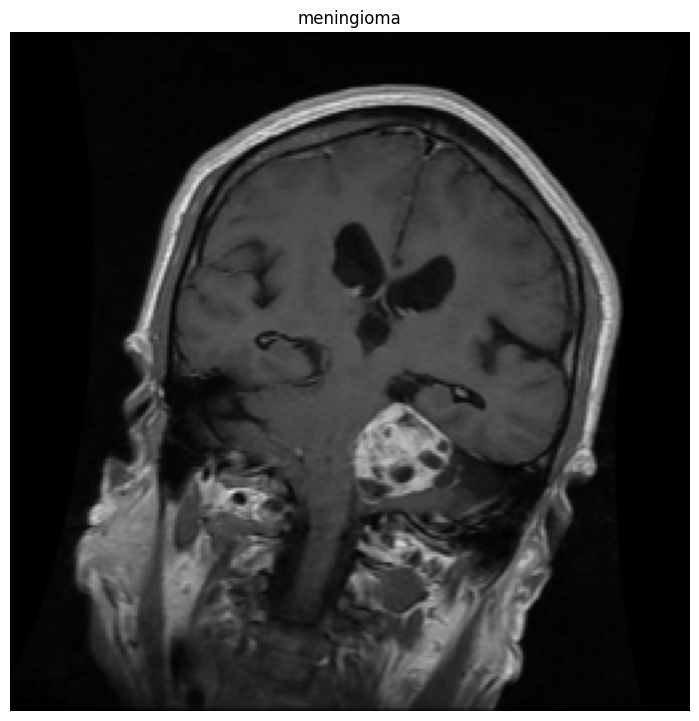

In [18]:

temp_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    training_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)
class_names = temp_ds_for_names.class_names
print(f"Detected Classes: {class_names}")

plt.figure(figsize=(30,30))

for images, labels in train_ds.take(1):
  for i in range(1):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [6]:
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:

model = models.Sequential([
    # Preprocessing layer: Resize and Rescale (Normalize pixel values to 0-1)
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255),

    #Detect basic features (edges)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),

    #Detect shapes (curves, circles)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #Detect complex textures (tumor patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #Deep features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #Deepest features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten: Convert 2D maps to 1D vector
    layers.Flatten(),

    # Classification Layers
    layers.Dense(64, activation='relu'),

    # Output Layer: 4 Neurons (for 4 classes: glioma, meningioma, notumor, pituitary)
    # Use 'softmax' because classes are mutually exclusive
    layers.Dense(4, activation='softmax')
])

model.build(input_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 2304)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,956 (1.06 MB)

 Trainable params: 277,956 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Compile

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "brain_tumor_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only = True
)

earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    verbose=1
)


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=test_ds,
    verbose=1
)

model.save("brain_tumor_custom_cnn.keras")

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.5601 - loss: 0.9605 - val_accuracy: 0.7666 - val_loss: 0.5591
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.8320 - loss: 0.4262 - val_accuracy: 0.8345 - val_loss: 0.4112
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.8893 - loss: 0.2932 - val_accuracy: 0.8467 - val_loss: 0.4241
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9243 - loss: 0.1996 - val_accuracy: 0.8497 - val_loss: 0.4023
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9429 - loss: 0.1464 - val_accuracy: 0.9039 - val_loss: 0.2608
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9522 - loss: 0.1260 - val_accuracy: 0.9252 - val_loss: 0.2171
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9623 - loss: 0.1049 - val_accuracy: 0.9367 - val_loss: 0.2023
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9683 - loss: 0.0840 -

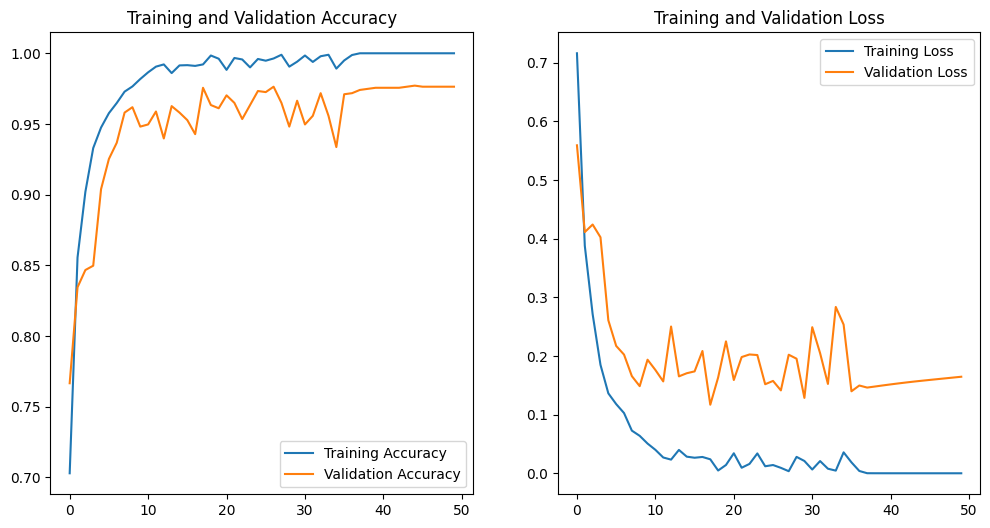

In [29]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12,6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [11]:
# Run evaluation on the test dataset
print("Evaluating on Test Data...")
score = model.evaluate(test_ds)

print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]*100:.2f}%")

Evaluating on Test Data...
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9860 - loss: 0.1557
Test Loss: 0.1646
Test Accuracy: 97.64%


Generating predictions...


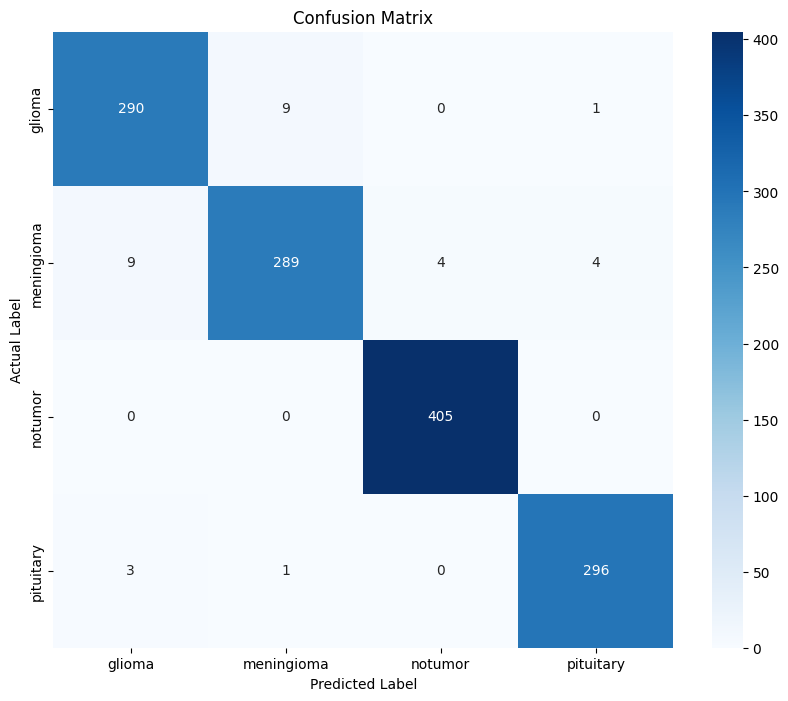

In [12]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


y_pred = []
y_true = []

print("Generating predictions...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())


cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
model.save("brain_tumor_custom_cnn.keras")

Min Pixel Value: 0.0
Max Pixel Value: 255.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Raw Prediction Scores:
Glioma: 0.0000  (Probability: 17.49%)
Meningioma: 1.0000  (Probability: 47.54%)
No Tumor: 0.0000  (Probability: 17.49%)
Pituitary: 0.0000  (Probability: 17.49%)


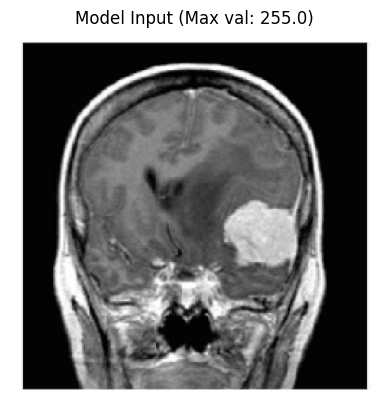

In [28]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


model = tf.keras.models.load_model('brain_tumor_custom_cnn.keras')


img_path = 'Image Path'
img = image.load_img(img_path, target_size=(256, 256))


img_array = image.img_to_array(img)


print(f"Min Pixel Value: {img_array.min()}")
print(f"Max Pixel Value: {img_array.max()}")




img_batch = tf.expand_dims(img_array, 0)

#Predict
preds = model.predict(img_batch)
score = tf.nn.softmax(preds[0])


class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
print("\nRaw Prediction Scores:")
for i, name in enumerate(class_names):
    print(f"{name}: {preds[0][i]:.4f}  (Probability: {score[i]*100:.2f}%)")


# If this image looks black, the model is blind.
plt.imshow(img_array.astype("uint8"))
plt.title(f"Model Input (Max val: {img_array.max()})")
plt.axis("off")
plt.show()